# Identitas Diri
- Nama: Muhammad Abiya Makruf
- Username: Abiyamf

## Import library

In [1]:
import random

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

## Data loading & Eksplorasi Data

In [3]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
raw_df = pd.read_csv(csv_url)

In [4]:
raw_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [5]:
raw_df.tail()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
53145,2023-10-19 19:00:00,28750.75,2.984059e+07,53.630054,109.926882,129.065981,7.459700
53146,2023-10-19 20:00:00,28715.38,4.997623e+07,53.531282,111.721905,129.268969,7.118597
53147,2023-10-19 21:00:00,28604.09,3.205666e+07,53.221944,113.055031,129.287930,6.210037
53148,2023-10-19 22:00:00,28649.65,2.200420e+07,53.332673,114.513131,129.219782,6.515616
53149,2023-10-19 23:00:00,28713.71,1.758298e+07,53.487941,116.161806,129.096002,6.963753


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [7]:
# Penentuan feature dan target
FEATURE = [i for i in raw_df.columns if i != 'Close' and i != 'Date']
TARGET = 'Close'

print("feature:", FEATURE)
print("target:", TARGET)

feature: ['Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
target: Close


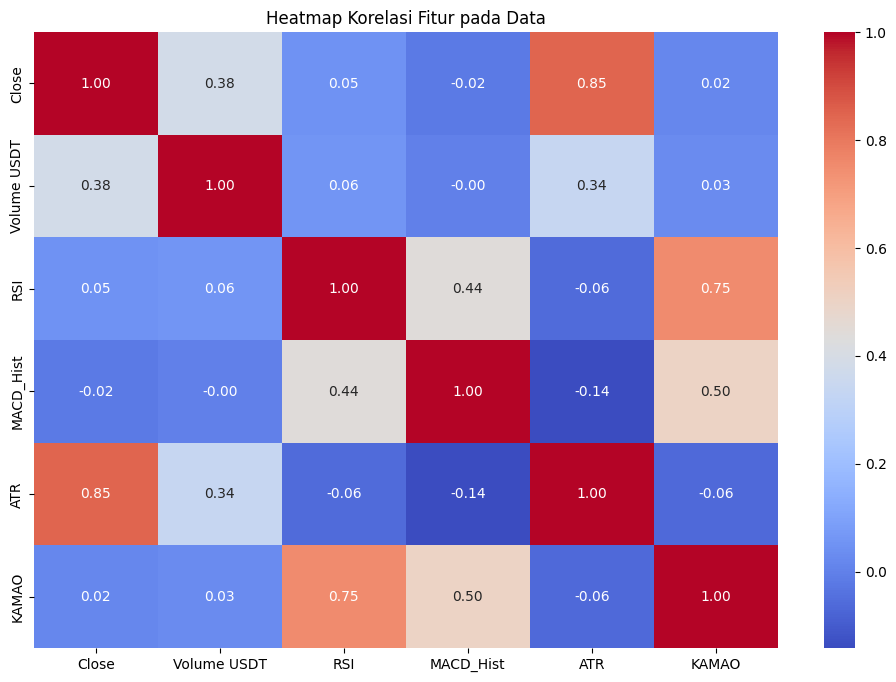

In [8]:
# Visualisasi heatmap korelasi antar fitur
plt.figure(figsize=(12, 8))
sns.heatmap(raw_df[[i for i in raw_df.columns if i != "Date"]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur pada Data')
plt.show()

## Data preparation

In [19]:
df = raw_df.copy()

In [20]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset=['Date']).reset_index(drop=True)

In [21]:
# Split data
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

train_df = df.iloc[:int(len(df) * TRAIN_RATIO)].reset_index(drop=True)
val_df = df.iloc[int(len(df) * TRAIN_RATIO):int(len(df) * (TRAIN_RATIO + VAL_RATIO))].reset_index(drop=True)
test_df = df.iloc[int(len(df) * (TRAIN_RATIO + VAL_RATIO)):].reset_index(drop=True)

len(train_df), len(val_df), len(test_df)

(11666, 2500, 2500)

In [22]:
train_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [23]:
# Scale data
scalers = {}
for col in FEATURE + ['Close']:
    scaler = MinMaxScaler()
    scaler.fit(train_df[[col]])
    scalers[col] = scaler

for col in FEATURE + ['Close']:
    train_df[col] = scalers[col].transform(train_df[[col]])
    val_df[col] = scalers[col].transform(val_df[[col]])
    test_df[col] = scalers[col].transform(test_df[[col]])


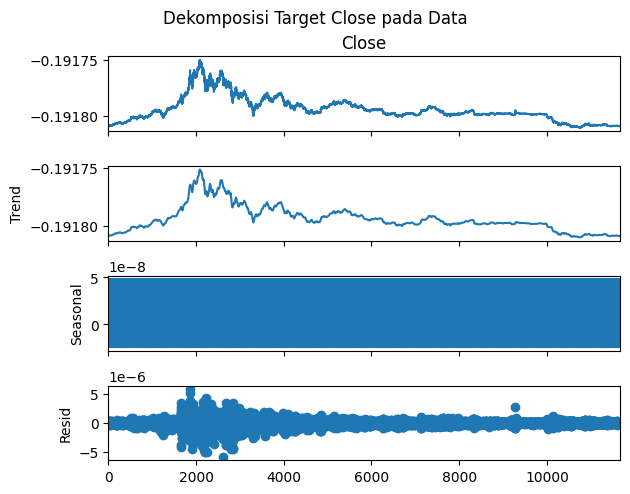

In [24]:
# Analisis dekomposisi untuk melihat komponen tren, musiman, dan residu
decomposition = seasonal_decompose(train_df[TARGET], model='additive', period=24)
decomposition.plot()
plt.suptitle('Dekomposisi Target Close pada Data', y=1.02)
plt.show()

In [25]:
WINDOW_SIZE = 72
HORIZON = 24

def make_supervised_windows(df, feature_columns, target_column, window_size=WINDOW_SIZE, horizon=HORIZON):
    feature_values = df[feature_columns].to_numpy(dtype=np.float32)
    target_values = df[target_column].to_numpy(dtype=np.float32)
    timestamps = df['Date'].to_numpy()

    X, y, y_timestamps = [], [], []
    for end_idx in range(window_size, len(df) - horizon + 1):
        start_idx = end_idx - window_size
        target_slice = slice(end_idx, end_idx + horizon)
        X.append(feature_values[start_idx:end_idx])
        y.append(target_values[target_slice].reshape(horizon, 1))
        y_timestamps.append(timestamps[target_slice])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    y_timestamps = np.asarray(y_timestamps)
    return X, y, y_timestamps

X_train, y_train, train_timestamps = make_supervised_windows(train_df, FEATURE, TARGET)
X_val, y_val, val_timestamps = make_supervised_windows(val_df, FEATURE, TARGET)
X_test, y_test, test_timestamps = make_supervised_windows(test_df, FEATURE, TARGET)

In [ ]:
BATCH_SIZE = 64
EPOCHS = 10

def make_tf_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(X), 2048), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_tf_dataset(X_train, y_train, shuffle=True)
val_ds = make_tf_dataset(X_val, y_val, shuffle=False)
test_ds = make_tf_dataset(X_test, y_test, shuffle=False)

## Baseline LSTM

In [27]:
baseline_lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(WINDOW_SIZE, len(FEATURE))),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(HORIZON),
    tf.keras.layers.Reshape((HORIZON, 1)),
], name='Baseline_LSTM_Model')

baseline_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()],
)

history_lstm_baseline = baseline_lstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

test_loss, test_mae = baseline_lstm_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

Epoch 1/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0015 - mean_absolute_error: 0.0188 - val_loss: 3.0036e-05 - val_mean_absolute_error: 0.0039
Epoch 2/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0840e-05 - mean_absolute_error: 0.0022 - val_loss: 6.4060e-06 - val_mean_absolute_error: 0.0018
Epoch 3/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.1369e-06 - mean_absolute_error: 0.0013 - val_loss: 3.6797e-06 - val_mean_absolute_error: 0.0013
Epoch 4/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.5577e-06 - mean_absolute_error: 9.0754e-04 - val_loss: 2.3859e-06 - val_mean_absolute_error: 0.0011
Epoch 5/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.7759e-07 - mean_absolute_error: 7.2179e-04 - val_loss: 1.3449e-06 - val_mean_absolute_error: 7.2896e-04
Epoch 6/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.7756e-07 - mean_absolute_error: 5.9605e-04 - val_loss: 9.7463e-07 - val_mean_absolute_error: 6.0412e-04
Epoch 7/20
181/181 ━━━━━━━━━━━

In [28]:
sample_prediction = baseline_lstm_model.predict(X_test[:1], verbose=0)[0, :, 0]
sample_actual = y_test[0, :, 0]

comparison_df = pd.DataFrame({
    'step': np.arange(1, HORIZON + 1),
    'actual_close_scaled': sample_actual,
    'predicted_close_scaled': sample_prediction,
})
comparison_df['difference'] = comparison_df['predicted_close_scaled'] - comparison_df['actual_close_scaled']
display(comparison_df)

,step,actual_close_scaled,predicted_close_scaled,difference
0,1,-0.191799,-0.191305,0.000493
1,2,-0.191799,-0.191568,0.000231
2,3,-0.191799,-0.190966,0.000833
3,4,-0.191799,-0.191097,0.000702
4,5,-0.191799,-0.191266,0.000533
5,6,-0.191798,-0.191712,0.000087
6,7,-0.191798,-0.190625,0.001173
7,8,-0.191798,-0.191363,0.000435
8,9,-0.191798,-0.191266,0.000533
9,10,-0.191798,-0.191623,0.000175
